# Fitness Advantage Analysis

Analyze the fitness advantage of a group of genotypes (peak supernode) over
external neighbors across drug concentrations.

1. **Explore graph** — load and visualize to identify the target group
2. **Compute fitness advantage** — 1-mut and 2-mut external neighbors
3. **Visualize** — box plot for publication

## 1. Explore Graph & Identify Target Group

In [4]:
import math
from fitness_landscape_graph.graph_analyzer import GraphAnalyzer, VisConfig

# Load graph (aztreonam, concentration 108.0)
graph_path = "../exp-01-reproduce-results/outputs/run1-reproduce-results/azt_108_0.graphml"
ga = GraphAnalyzer(graph_path)

# Visualize — node IDs are shown in the plot
config = VisConfig()
config.x_mode = "average"
config.figure_width = 1600
config.figure_height = 1100
config.edge_width_scaling = lambda w: max(0.5, min(3.0, math.log1p(w) * 0.3))

fig = ga.plot(config=config)
fig.show()

In [5]:
# From the plot, identify the node of interest and extract its genotypes
# Example: use the peak node (highest fitness peak)
group_genotypes = ga.get_peak_genotypes(rank=0)
print(f"Group size: {len(group_genotypes)}")
print(f"Sample genotypes: {list(group_genotypes)[:5]}")

Group size: 185
Sample genotypes: ['.K..NT..K....', '.KVKS...K.M..', 'PK.KNT..K....', '..VKNT..K.M..', '..LKNT..K....']


## 2. Compute Fitness Advantage

In [6]:
import polars as pl
from fitness_landscape_graph.preprocess import preprocess_data
from fitness_landscape_graph.fitness_advantage import FitnessAdvantageAnalyzer

# Load data
project_root = "../.."
processed_data = preprocess_data(
    amp_path=f"{project_root}/data/raw/combined-auc/genotype_auc_sorted_ampicillin.csv",
    azt_path=f"{project_root}/data/raw/combined-auc/genotype_auc_sorted_aztreonam.csv",
    amp_pairs_path=f"{project_root}/data/processed/amp_pairs.csv",
    azt_pairs_path=f"{project_root}/data/processed/azt_pairs.csv",
    clean_nulls_flag=True,
)

azt_long_df = processed_data["azt"]["long"]
azt_pairs_df = processed_data["azt"]["pairs"]

print(f"Long table: {len(azt_long_df)} rows")
print(f"Pairs table: {len(azt_pairs_df)} rows")
print(f"Concentrations: {sorted(azt_long_df['concentration'].unique().to_list())}")

Long table: 442352 rows
Pairs table: 3980880 rows
Concentrations: [0.0, 0.44, 1.33, 4.0, 12.0, 36.0, 108.0, 324.0]


In [7]:
# Compute fitness advantage
analyzer = FitnessAdvantageAnalyzer(azt_pairs_df, azt_long_df)
result_df = analyzer.compute_fitness_advantage(
    group_genotypes=group_genotypes,
    max_distance=2,
)

print(f"Total comparisons: {result_df.height}")
result_df.head(10)

Total comparisons: 204776


group_member,neighbor,distance,group_member_fitness,neighbor_fitness,fitness_diff,concentration
str,str,i32,f64,f64,f64,f64
"""P..KST..K....""","""P..KST..KC...""",1,3.076938,3.222969,-0.146031,0.0
""".K.KN...K.M.D""",""".K.KN.....M.D""",1,3.274293,3.080143,0.194151,0.0
""".K.KS...K...D""",""".K.KS.......D""",1,3.238489,3.342597,-0.104108,0.0
""".KVKN.T.K....""",""".KVKNTT.K....""",1,3.161575,3.22501,-0.063436,0.0
""".K.KNT..K.MQ.""",""".K..NT..K.MQ.""",1,3.3344,3.223188,0.111212,0.0
"""...KHT..K.M..""","""...KHT..K.M.D""",1,3.135429,3.134853,0.000575,0.0
""".KVKST..K.M..""",""".KV.ST..K.M..""",1,3.092071,3.007645,0.084426,0.0
"""P..KH...K.M..""","""P..KH...KCM..""",1,3.17675,3.287203,-0.110452,0.0
"""...KN..SK....""","""...KN..SKS...""",1,3.044317,3.222307,-0.177991,0.0


In [8]:
# Summary statistics
import numpy as np

for conc in sorted(result_df["concentration"].unique().to_list()):
    conc_data = result_df.filter(pl.col("concentration") == conc)
    for dist in sorted(conc_data["distance"].unique().to_list()):
        dist_data = conc_data.filter(pl.col("distance") == dist)
        diffs = dist_data["fitness_diff"].to_list()
        if diffs:
            print(
                f"  conc={conc:>6.1f}  dist={dist}  "
                f"n={len(diffs):>5d}  "
                f"median={np.median(diffs):>+.3f}  "
                f"mean={np.mean(diffs):>+.3f}"
            )

  conc=   0.0  dist=1  n= 2232  median=+0.007  mean=+0.011
  conc=   0.0  dist=2  n=23365  median=+0.010  mean=+0.012
  conc=   0.4  dist=1  n= 2232  median=+0.020  mean=+0.066
  conc=   0.4  dist=2  n=23365  median=+0.052  mean=+0.158
  conc=   1.3  dist=1  n= 2232  median=+0.042  mean=+0.142
  conc=   1.3  dist=2  n=23365  median=+0.100  mean=+0.321
  conc=   4.0  dist=1  n= 2232  median=+0.074  mean=+0.284
  conc=   4.0  dist=2  n=23365  median=+0.232  mean=+0.586
  conc=  12.0  dist=1  n= 2232  median=+0.220  mean=+0.597
  conc=  12.0  dist=2  n=23365  median=+1.088  mean=+1.037
  conc=  36.0  dist=1  n= 2232  median=+1.246  mean=+1.309
  conc=  36.0  dist=2  n=23365  median=+2.185  mean=+1.788
  conc= 108.0  dist=1  n= 2232  median=+2.351  mean=+2.199
  conc= 108.0  dist=2  n=23365  median=+2.565  mean=+2.410
  conc= 324.0  dist=1  n= 2232  median=+0.253  mean=+0.836
  conc= 324.0  dist=2  n=23365  median=+0.392  mean=+0.959


## 3. Visualization

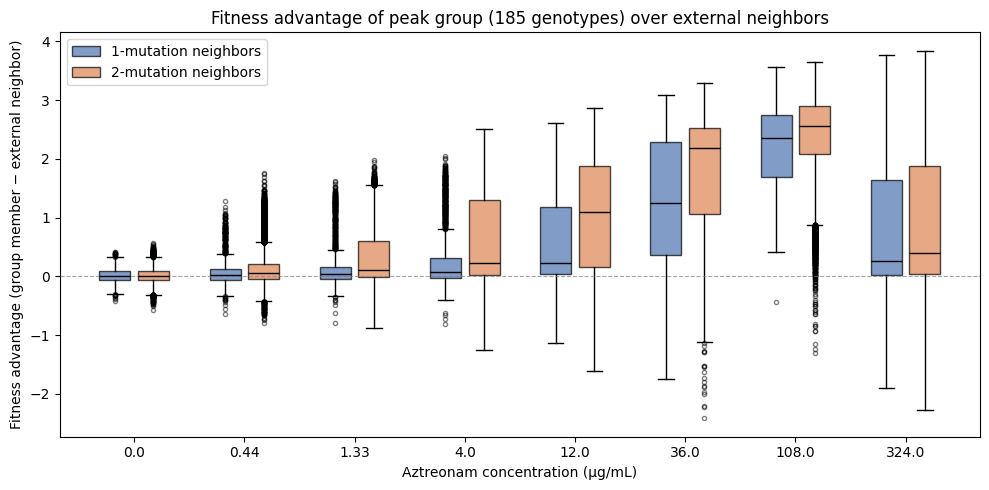

In [10]:
import matplotlib.pyplot as plt

concentrations = sorted(result_df["concentration"].unique().to_list())
distances = sorted(result_df["distance"].unique().to_list())

fig, ax = plt.subplots(figsize=(10, 5))

n_conc = len(concentrations)
n_dist = len(distances)
width = 0.35
x_base = np.arange(n_conc)

colors = {1: "#4C72B0", 2: "#DD8452"}

for i, dist in enumerate(distances):
    dist_df = result_df.filter(pl.col("distance") == dist)
    box_data = []
    positions = []
    for j, conc in enumerate(concentrations):
        conc_data = dist_df.filter(pl.col("concentration") == conc)["fitness_diff"].to_list()
        if conc_data:
            box_data.append(conc_data)
            positions.append(x_base[j] + (i - (n_dist - 1) / 2) * width)

    if not box_data:
        continue

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        showfliers=True,
        flierprops={"markersize": 3, "alpha": 0.5},
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(colors.get(dist, "grey"))
        patch.set_alpha(0.7)
    for median_line in bp["medians"]:
        median_line.set_color("black")
    bp["boxes"][0].set_label(f"{dist}-mutation neighbors")

ax.axhline(y=0, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_xticks(x_base)
ax.set_xticklabels([str(c) for c in concentrations])
ax.set_xlabel("Aztreonam concentration (µg/mL)")
ax.set_ylabel("Fitness advantage (group member − external neighbor)")
ax.set_title(f"Fitness advantage of peak group ({len(group_genotypes)} genotypes) over external neighbors")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Save figure and data
import os

output_dir = "./outputs/fitness-advantage-azt-12"
os.makedirs(output_dir, exist_ok=True)

fig.savefig(f"{output_dir}/fitness_advantage_boxplot.pdf", bbox_inches="tight", dpi=300)
fig.savefig(f"{output_dir}/fitness_advantage_boxplot.png", bbox_inches="tight", dpi=300)
result_df.write_csv(f"{output_dir}/fitness_advantage_data.csv")

print(f"Saved to {output_dir}")